<a href="https://colab.research.google.com/github/zzzer0-wav/Melbourne_Housing/blob/main/notebooks/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Cleaning and analysis project of 'Melbourne housing' dataset

### Step 1 - loading dataset

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
FILE_IN = 'https://raw.githubusercontent.com/zzzer0-wav/Melbourne_Housing/refs/heads/main/data/melb_data.csv'
FILE_OUT = 'clean_melb_data'
df_origin = pd.read_csv(FILE_IN)
df = df_origin.copy()
RANDOM_STATE=42

In [38]:
pd.set_option('display.max_columns', None)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns='Unnamed: 0')

### Step 2 - first look

In [39]:
display(df.head())
display(df.dtypes)
print('Rows:', df.shape[0], 'Columns:', df.shape[1])

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


Rows: 13580 Columns: 21


In [40]:
round(df.describe(), 2)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


In [41]:
# Missing values table
print(f'Missing: {df.isna().sum().sum()} / {df.size}')

missing = df.isna().sum()
missing_pct = round(df.isna().mean() * 100, 2)
missing_table = pd.DataFrame({
    'type': df.dtypes.astype(str),
    'count_nan':missing,
    'missing_pct':missing_pct
})

missing_table.sort_values(['missing_pct', 'count_nan'], ascending=False)

Missing: 13256 / 285180


,type,count_nan,missing_pct
BuildingArea,float64,6450,47.50
YearBuilt,float64,5375,39.58
CouncilArea,object,1369,10.08
Car,float64,62,0.46
Suburb,object,0,0.00
Address,object,0,0.00
Rooms,int64,0,0.00
Type,object,0,0.00
Price,float64,0,0.00
Method,object,0,0.00


### Step 3 - cleaning

In [42]:
clean = df.copy()
print(clean.columns)
if clean.columns[0] == ['Unnamed: 0']:
  clean = clean.drop(columns=['Unnamed: 0'])
print()
print(clean.info())

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13

In [43]:
# Rename columns
clean = clean.rename(columns={
    'Suburb':'suburb',
    'Address':'address',
    'Rooms':'rooms',
    'Type':'type',
    'Price':'price',
    'Method':'method',
    'SellerG':'seller_g',
    'Date':'date',
    'Distance':'distance',
    'Postcode':'postcode',
    'Bedroom2':'bedroom2',
    'Bathroom':'bathroom',
    'Car':'car',
    'Landsize':'landsize',
    'BuildingArea':'building_area',
    'YearBuilt':'year_built',
    'CouncilArea':'council_area',
    'Lattitude':'lattitude',
    'Longtitude':'longtitude',
    'Regionname':'region_name',
    'Propertycount':'property_count'
})
print(list(clean.columns))

['suburb', 'address', 'rooms', 'type', 'price', 'method', 'seller_g', 'date', 'distance', 'postcode', 'bedroom2', 'bathroom', 'car', 'landsize', 'building_area', 'year_built', 'council_area', 'lattitude', 'longtitude', 'region_name', 'property_count']


In [44]:
# Columns types
clean['date'] = pd.to_datetime(clean['date'], format='%d/%m/%Y')
clean['postcode'] = clean['postcode'].astype('int64')
clean['bedroom2'] = clean['bedroom2'].astype('int8')
clean['bathroom'] = clean['bathroom'].astype('int8')


In [45]:
# Impossible building_year
mask = (clean['year_built'] < 1800) | (clean['year_built'] > 2018)
clean.loc[mask, 'year_built'] = np.nan
print(f'Oldest houses: \n{clean.year_built.sort_values().head(10)}')

# Removing wrong buildding_area values
clean.loc[clean['building_area']<15, 'building_area'] = np.nan
print(f'\nSmallest houses:\n {clean['building_area'].sort_values().head(10)}')

# 0 -> NaN values
zero_cols = ['landsize', 'building_area']

for col in zero_cols:
    clean.loc[clean[col]==0, col] = np.nan

# Duplicates check
print(f'\nDuplicated found: {clean.duplicated().sum()}')
# clean.drop_duplicates()

Oldest houses: 
2079     1830.0
5860     1850.0
4843     1850.0
5405     1850.0
2554     1850.0
2530     1854.0
5536     1856.0
12158    1857.0
11503    1860.0
8583     1860.0
Name: year_built, dtype: float64

Smallest houses:
 8364    15.0
6123    15.0
4154    16.0
9945    16.0
3309    18.0
31      18.0
6431    18.0
2336    18.0
5671    18.0
3491    18.0
Name: building_area, dtype: float64

Duplicated found: 0


In [46]:
clean.shape

(13580, 21)

After deleting 0 values in build area I found more weird min values from 1 to 15. Even smallest apartment cant be smaller then 15 m². So swaping values 0-14 to nan is good decision for analysis.

In [47]:
missing = clean.isna().sum()
missing_pct = round(clean.isna().mean() * 100, 2)
missing_table = pd.DataFrame({
    'type': clean.dtypes.astype(str),
    'missing':missing,
    'missing_pct':missing_pct
})

missing_table.sort_values(['missing', 'missing_pct'], ascending=False)

,type,missing,missing_pct
building_area,float64,6530,48.09
year_built,float64,5376,39.59
landsize,float64,1939,14.28
council_area,object,1369,10.08
car,float64,62,0.46
suburb,object,0,0.00
address,object,0,0.00
rooms,int64,0,0.00
type,object,0,0.00
price,float64,0,0.00


### Step 4 - EDA

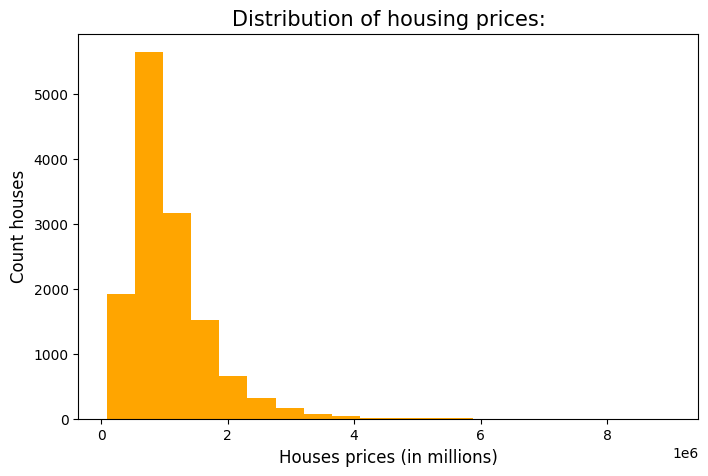

In [48]:
# Histogram price
plt.figure(figsize=(8, 5))
plt.hist(clean['price'], bins=20, color='orange')
plt.title('Distribution of housing prices:', fontsize=15)
plt.xlabel('Houses prices (in millions)', fontsize=12)
plt.ylabel("Count houses", fontsize=12);

Text(0, 0.5, 'Number of houses:')

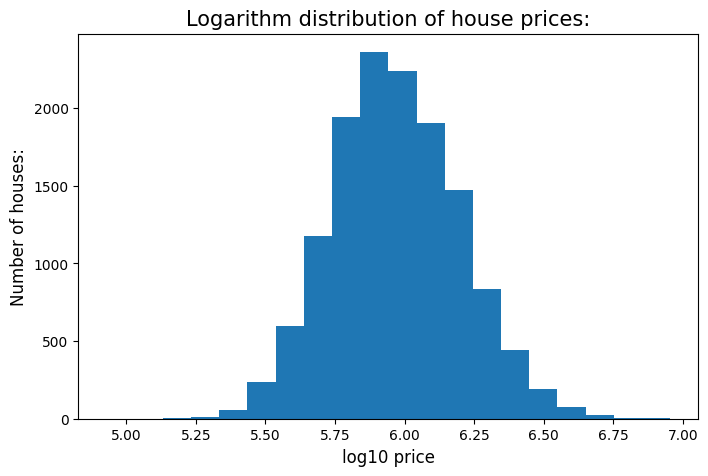

In [49]:
# Histogram logafirm
plt.figure(figsize=(8, 5))
plt.hist(np.log10(clean['price']), bins=20)
plt.title('Logarithm distribution of house prices:', fontsize=15)
plt.xlabel('log10 price', fontsize=12)
plt.ylabel('Number of houses:', fontsize=12)

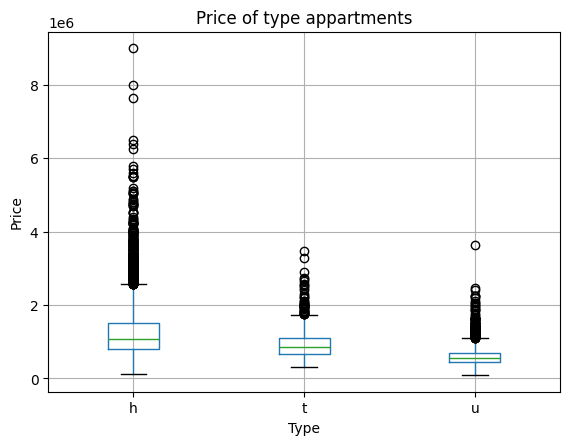

In [50]:
# Boxplot price by type
clean.boxplot(column='price', by='type')
plt.suptitle('')
plt.title('Price of type appartments')
plt.xlabel('Type')
plt.ylabel('Price');

In [51]:
# Correlation check
num = clean.select_dtypes('number')
num.corr()['price'].drop('price').sort_values(key=abs, ascending=False).round(3)

,price
rooms,0.497
bedroom2,0.476
bathroom,0.467
year_built,-0.332
car,0.239
lattitude,-0.213
longtitude,0.204
distance,-0.163
postcode,0.108
building_area,0.091


In [52]:
# Correlation checking without NaN
df_drop = df_origin.copy()
df_drop = df_drop.dropna()
print(f'before drop: {df_origin.shape}')
print(f'after drop: {df_drop.shape}')
num = df_drop.select_dtypes('number')
num.corr()['Price'].drop('Price').sort_values(key=abs, ascending=False).round(3)

before drop: (13580, 21)
after drop: (6196, 21)


,Price
Rooms,0.534
BuildingArea,0.531
Bedroom2,0.515
Bathroom,0.504
YearBuilt,-0.305
Car,0.262
Lattitude,-0.214
Longtitude,0.212
Distance,-0.149
Postcode,0.126


In [53]:
num.corr().round(3)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
Rooms,1.000,0.534,0.284,0.051,0.952,0.614,0.423,0.099,0.608,-0.068,0.016,0.088,-0.111
Price,0.534,1.000,-0.149,0.126,0.515,0.504,0.262,0.081,0.531,-0.305,-0.214,0.212,-0.046
Distance,0.284,-0.149,1.000,0.406,0.290,0.125,0.274,0.059,0.160,0.246,-0.094,0.222,-0.084
Postcode,0.051,0.126,0.406,1.000,0.054,0.110,0.044,0.026,0.078,0.024,-0.425,0.471,0.065
Bedroom2,0.952,0.515,0.290,0.054,1.000,0.618,0.426,0.097,0.593,-0.056,0.021,0.086,-0.109
Bathroom,0.614,0.504,0.125,0.110,0.618,1.000,0.341,0.076,0.534,0.158,-0.072,0.116,-0.067
Car,0.423,0.262,0.274,0.044,0.426,0.341,1.000,0.118,0.334,0.109,0.012,0.055,-0.046
Landsize,0.099,0.081,0.059,0.026,0.097,0.076,0.118,1.000,0.085,0.027,0.006,0.033,-0.018
BuildingArea,0.608,0.531,0.160,0.078,0.593,0.534,0.334,0.085,1.000,0.006,-0.038,0.104,-0.066
YearBuilt,-0.068,-0.305,0.246,0.024,-0.056,0.158,0.109,0.027,0.006,1.000,0.057,-0.002,-0.001


The most expensive type of housing is h (house) as we can see on boxplot. Housing has a lot of outliers, but his biggest median shows most expensive type. Most cheapest type is u (unit/apartment) with lowest median. It's logical, cause houses have a lot bigger area compare to compact apartments. Distance has a weak, indirect correlation (-0.163), means the farther the house is from center - the cheaper it is, but not by much.

On the full correlation matrix we see rooms and bedrooms (0.952) have really strong correlation, this is almost perfect duplication, since more rooms almost always means more bedrooms.

Building area and rooms also have big correlation (0.608), but this is not a duplication, both features are important. Rooms shows numbers of rooms and area shows total square footage and both should be kept for analysis.

### Step 5 - feature engineering

In [54]:
fe = clean.copy()

In [55]:
# Creating new features

# date
fe['sale_year'] = fe['date'].dt.year
fe['sale_month'] = fe['date'].dt.month

# building age
fe['age'] = fe['sale_year'] - fe['year_built']

# deleting age=0
fe.loc[fe['age']<0, 'age'] = np.nan
print(fe[fe['age']<0])

# creating num bool features
columns = ['year_built', 'building_area']
for col in columns:
    fe[f'has_{col}'] = fe[col].notna().astype(int)
# or fe['has_buildingarea'] = fe['building_area'].notna().astype(int)

# Deleting useless
drop_cols = ['bedroom2', 'address', 'seller_g', 'suburb', 'postcode', 'date', 'year_built', 'building_area']
fe = fe.drop(columns=drop_cols)
fe


Empty DataFrame
Columns: [suburb, address, rooms, type, price, method, seller_g, date, distance, postcode, bedroom2, bathroom, car, landsize, building_area, year_built, council_area, lattitude, longtitude, region_name, property_count, sale_year, sale_month, age]
Index: []


,rooms,type,price,method,distance,bathroom,car,landsize,council_area,lattitude,longtitude,region_name,property_count,sale_year,sale_month,age,has_year_built,has_building_area
0,2,h,1480000.0,S,2.5,1,1.0,202.0,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0,2016,12,NaN,0,0
1,2,h,1035000.0,S,2.5,1,0.0,156.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0,2016,2,116.0,1,1
2,3,h,1465000.0,SP,2.5,2,0.0,134.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0,2017,3,117.0,1,1
3,3,h,850000.0,PI,2.5,2,1.0,94.0,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0,2017,3,NaN,0,0
4,4,h,1600000.0,VB,2.5,1,2.0,120.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0,2016,6,2.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,4,h,1245000.0,S,16.7,2,2.0,652.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0,2017,8,36.0,1,0
13576,3,h,1031000.0,SP,6.8,2,2.0,333.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0,2017,8,22.0,1,1
13577,3,h,1170000.0,S,6.8,2,4.0,436.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0,2017,8,20.0,1,0
13578,4,h,2500000.0,PI,6.8,1,5.0,866.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0,2017,8,97.0,1,1


### Step 6 - preparation for modeling

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# target and features
y = fe['price']
X = fe.drop(columns=['price'])

# dividing columns into cat and num
cat_cols = ['type', 'method', 'region_name', 'council_area']
num_cols = [c for c in X.columns if c not in cat_cols]

# Coding cat and num columns (ColumnTransformer)
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy='most_frequent')),
        ("ohe", OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

# dividing data on train & test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)


print(f'Train: {X_train.shape[0]}, / {X_test.shape[0]}')
print(f'Numeric features: {num_cols}')
print(f'Categorial features: {cat_cols}')

Train: 10864, / 2716
Numeric features: ['rooms', 'distance', 'bathroom', 'car', 'landsize', 'lattitude', 'longtitude', 'property_count', 'sale_year', 'sale_month', 'age', 'has_year_built', 'has_building_area']
Categorial features: ['type', 'method', 'region_name', 'council_area']


### Step 7 - model and forecast

In [57]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Small function that teach model and print metrics
def evaluate(model, name):
  pipe = Pipeline([
      ('prep', preprocess),
      ('model', model)
  ])
  pipe.fit(X_train, y_train)
  pred = pipe.predict(X_test)
  return pipe, {
      'model':name,
      'MAE':round(mean_absolute_error(y_test, pred)),
      'RMSE':round(np.sqrt(mean_squared_error(y_test, pred))),
      'R2':round(r2_score(y_test, pred), 3)
  }

# Calling evaluate
_, r0 = evaluate(DummyRegressor(strategy='mean'), 'базова лiнiя (mean)')
_, r1 = evaluate(LinearRegression(), 'лiнйна регресiя')
rf_pipe, r2 = evaluate(
    RandomForestRegressor(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'Random Forest'
)

pd.DataFrame([r0, r1, r2])

,model,MAE,RMSE,R2
0,базова лiнiя (mean),461258,630259,-0.000
1,лiнйна регресiя,259610,379185,0.638
2,Random Forest,169292,277514,0.806


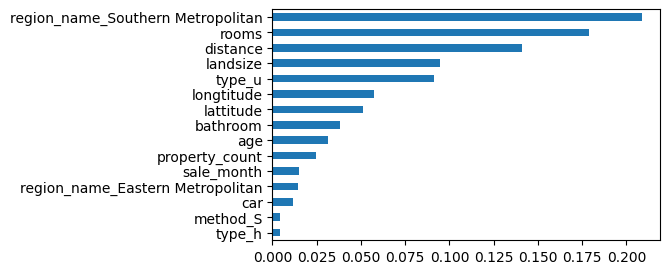

,0
region_name_Southern Metropolitan,0.209
rooms,0.179
distance,0.141
landsize,0.095
type_u,0.091
longtitude,0.058
lattitude,0.051
bathroom,0.038
age,0.031
property_count,0.024


In [58]:
ohe_names = rf_pipe.named_steps['prep'].named_transformers_['cat'] \
            .named_steps['ohe'].get_feature_names_out(cat_cols)

feat_names = list(num_cols) + list(ohe_names)
imp = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feat_names) \
      .sort_values(ascending=False).head(15)

plt.figure(figsize=(5, 3))
imp[::-1].plot.barh()
plt.show()

imp.round(3)

### Step 8 - conclusions and README

In [59]:
# візьміть один рядок із тесту як "новий" об'єкт
#  - example = X_test.iloc[[0]]
# зробіть прогноз навченим лісом і порівняйте зі справжньою ціною:
#  - прогноз: pipe.predict(example)
#  - справжня ціна: y_test.iloc[0]
# ...

In [60]:
# Taking first home from test data
example = X_test.iloc[[0]]

# Our model's predict
predicted_price = rf_pipe.predict(example)[0]

# Watching real price
real_price = y_test.iloc[0]

# Results
print(f"Model's predict: ${predicted_price:,.0f}")
print(f"Real house price: ${real_price:,.0f}")
print(f"Error ${abs(predicted_price - real_price):,.0f}")

Model's predict: $2,318,500
Real house price: $2,600,000
Error $281,500
